In [393]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [394]:
torch.__version__

'2.14.0+cu126'

## data creation 

In [395]:
weights = .7
bias = .3
X = torch.arange(0,1,.02).unsqueeze(dim=1)
y = X * weights + bias

In [396]:
len(X), len(y)

(50, 50)

In [397]:
train_split = int(len(X)* .8)
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]


In [398]:
len(X), len(y), len(X_train), len(y_train), len(X_test), len(y_test)

(50, 50, 40, 40, 10, 10)

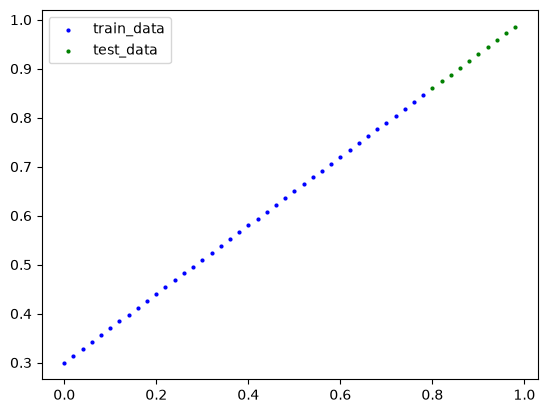

In [399]:
def plot_prediction(
        train_data = X_train,
        test_data = X_test,
        train_labels = y_train,
        test_labels = y_test,
        predictions = None):
    plt.Figure(figsize=(10,7))
    plt.scatter(train_data, train_labels, label= "train_data", c= "blue", s=4)
    plt.scatter(test_data, test_labels, label= "test_data", c="green", s=4)
    if predictions is not None:
        plt.scatter(test_data, predictions, label= "predictions", s=4, c= "red")

    plt.legend()
    plt.show

plot_prediction()

## model creation

In [400]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, 
                                                dtype=torch.float,
                                                requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, 
                                                dtype=torch.float,
                                                requires_grad=True))

    def forward(self, x: torch.Tensor) -> torch.Tensor: 
        return self.weights * x + self.bias

In [401]:
torch.manual_seed(42)
lr_model = LinearRegressionModel()
# list(lr_model.parameters())
lr_model.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

## model prediction

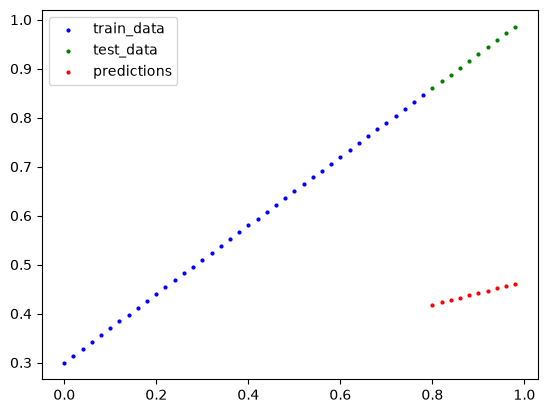

In [402]:
with torch.inference_mode():    # the inference mode disables all the internal things pytorch does (grad tracking and version counting and so on) 
                                # which is not needed in the training process for better optimization 
    y_pred = lr_model(y_test)

y_pred

plot_prediction(predictions=y_pred)

## loss and optimizing

In [403]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(lr_model.parameters(), lr= .01)

In [404]:
epochs = 200
weights_list = []
bias_list = []
loss_list = []
for epoch in range(epochs):
    lr_model.train()
    y_pred = lr_model(X_train)

    loss = loss_fn(y_pred, y_train)
    loss_list.append(loss.detach().clone())
    # print(loss)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    weights_list.append(lr_model.weights.detach().clone())
    bias_list.append(lr_model.bias.detach().clone())

    lr_model.eval()

# print(lr_model.state_dict())

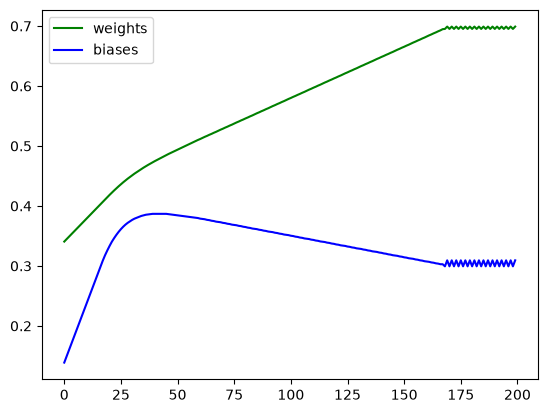

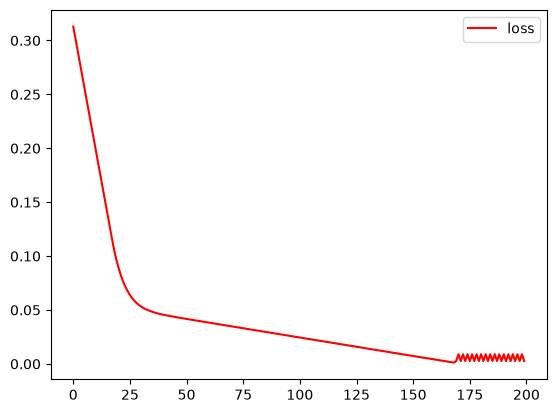

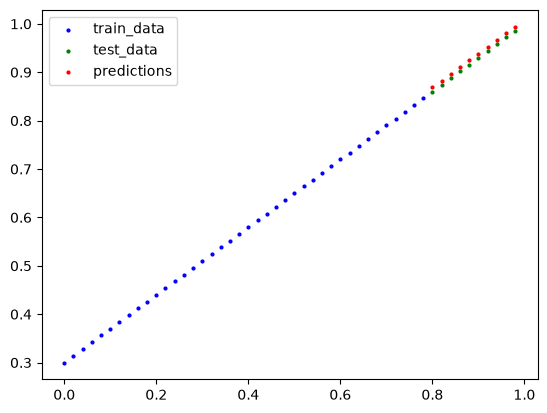

In [406]:
def param_plot(weights_list = weights_list, 
               bias_list = bias_list):
    plt.Figure(figsize=(10,7))

    plt.plot(weights_list, c = "green", label= "weights")
    plt.plot(bias_list, c = "blue", label= "biases")
    plt.legend()
    plt.show()

    plt.plot(loss_list, c="red", label="loss")
    plt.legend()
    plt.show()

param_plot()
plot_prediction(predictions=lr_model(X_test).detach().clone())